In [1]:
# Instalacja wszystkich wymaganych pakietów
!pip install shap lime xgboost scikit-learn xlrd openpyxl ucimlrepo kagglehub[pandas-datasets]

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import urllib.request
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import LabelEncoder
import shap
import lime
import lime.lime_tabular
from scipy.stats import spearmanr
import warnings
from ucimlrepo import fetch_ucirepo
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=07cc9bc253c339c49af5246d176b354bb176ec4d604de230986c001d88afd55d
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


Pobieranie bazy: Credit_Risk...
Pobieranie bazy: Telco_Churn...


100%|██████████| 955k/955k [00:00<00:00, 61.6MB/s]

Pobieranie bazy: HR_Attrition...


100%|██████████| 223k/223k [00:00<00:00, 19.7MB/s]


--- Credit_Risk ---


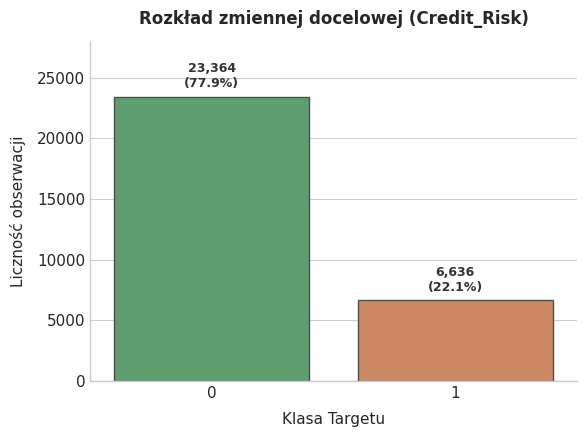

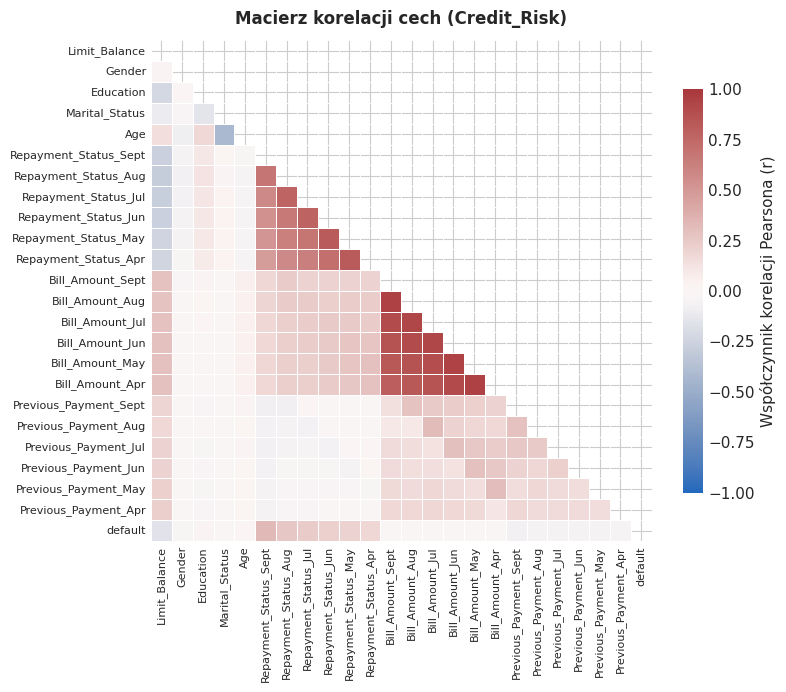

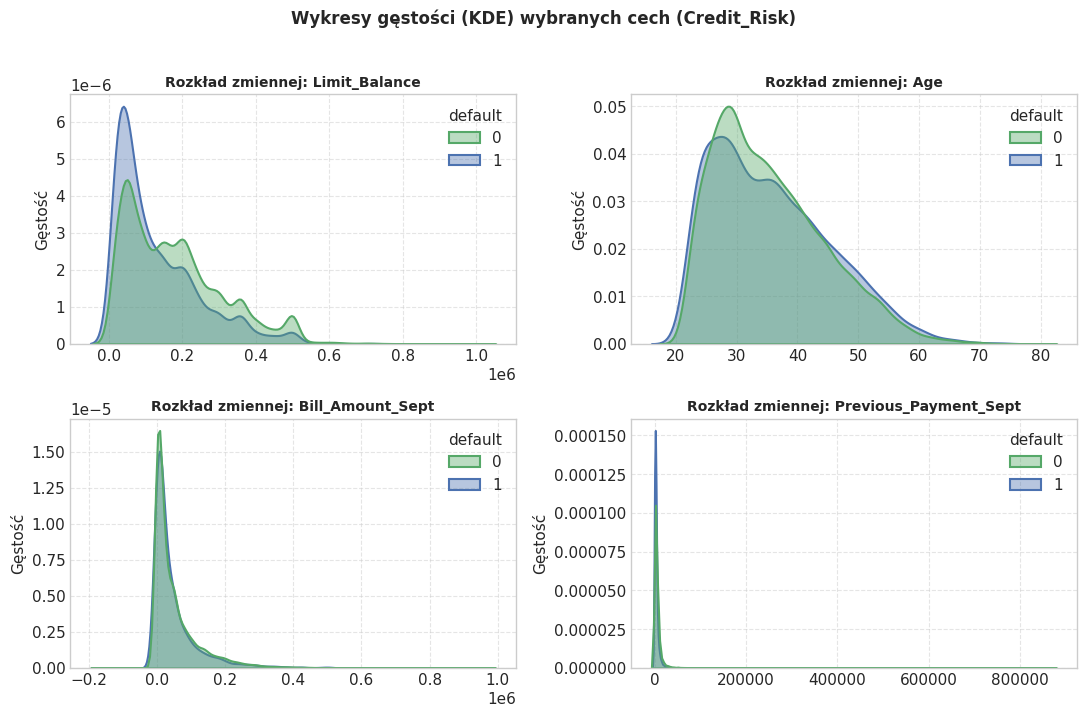


--- Telco_Churn ---


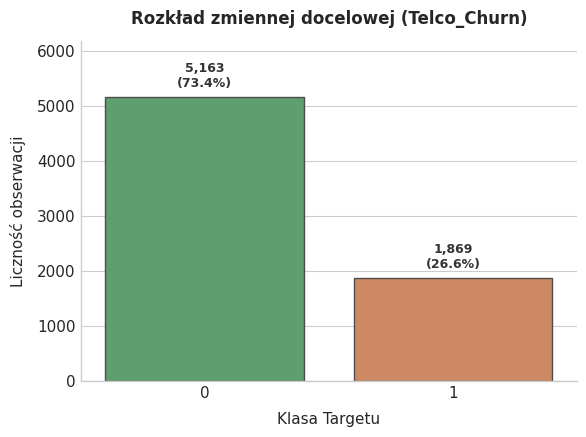

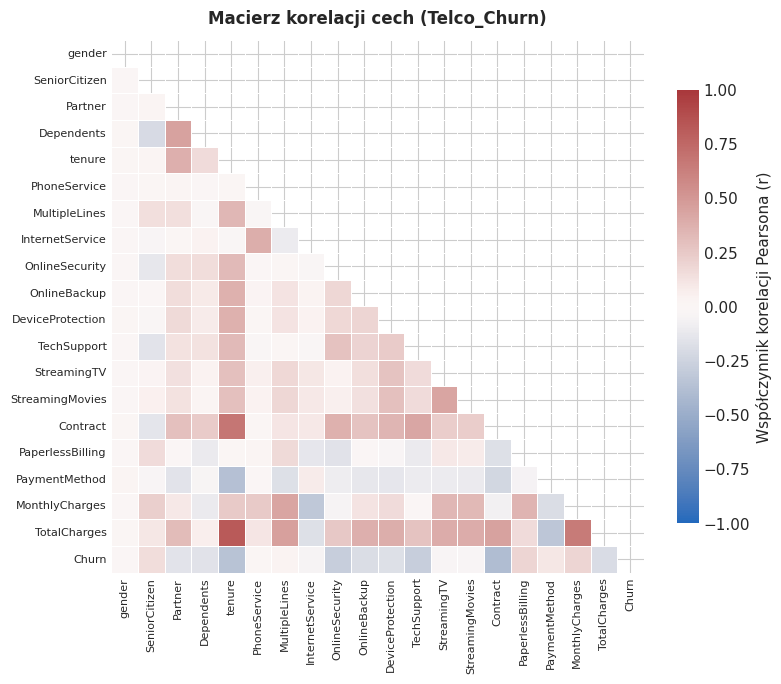

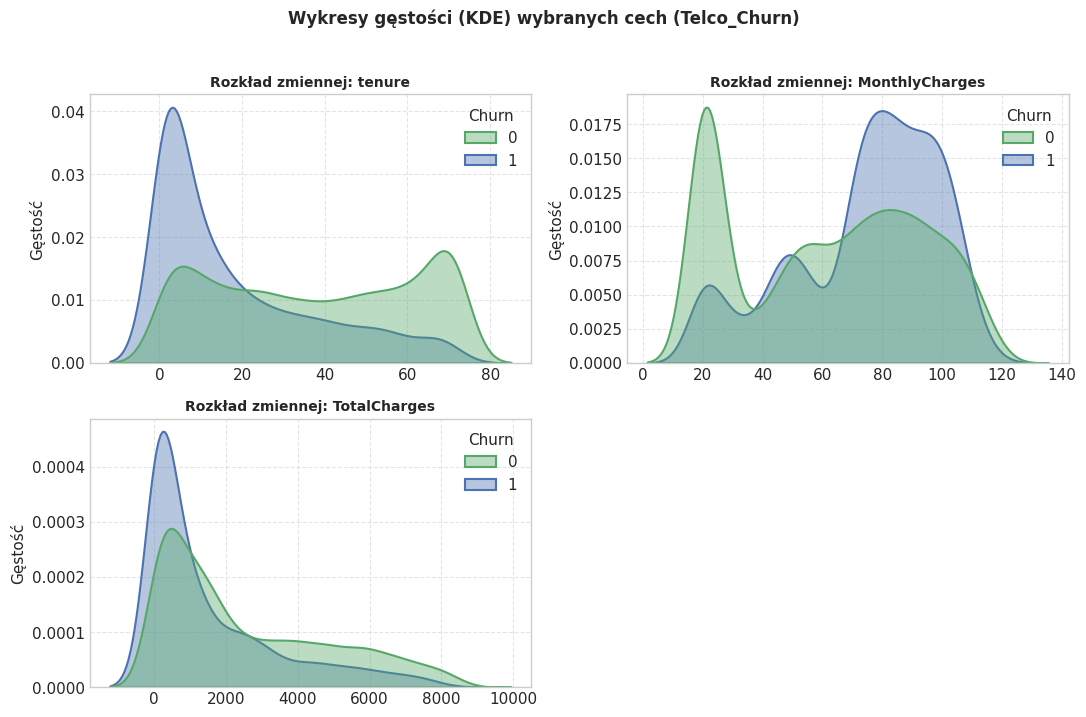


--- HR_Attrition ---


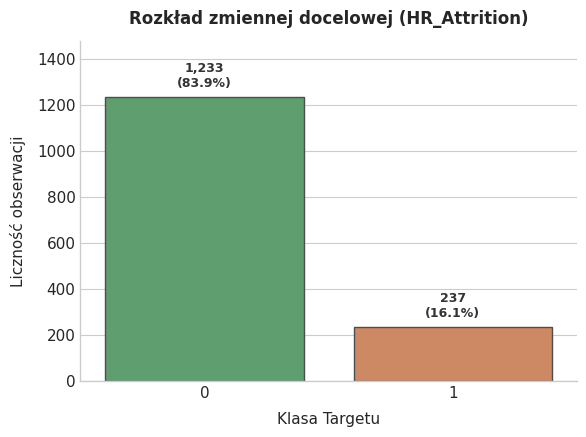

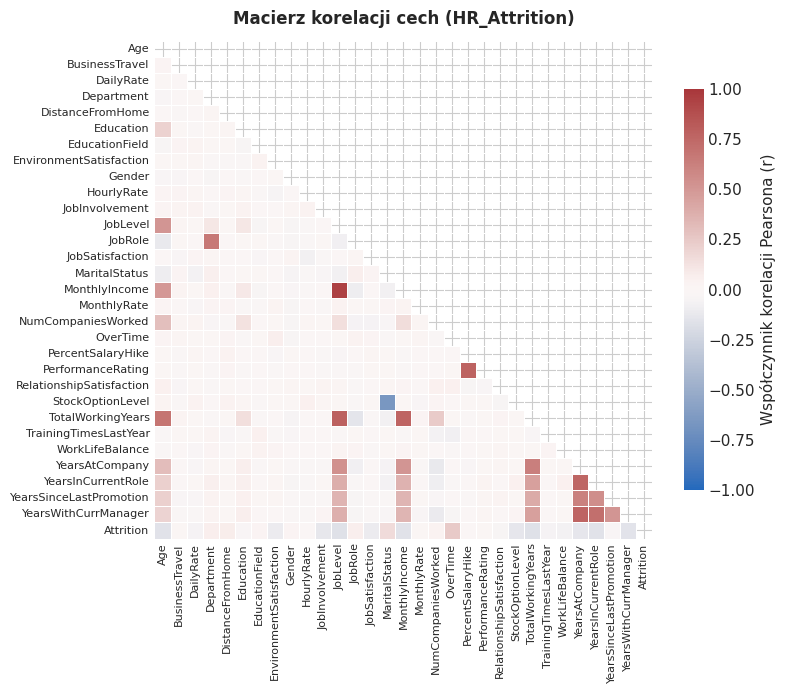

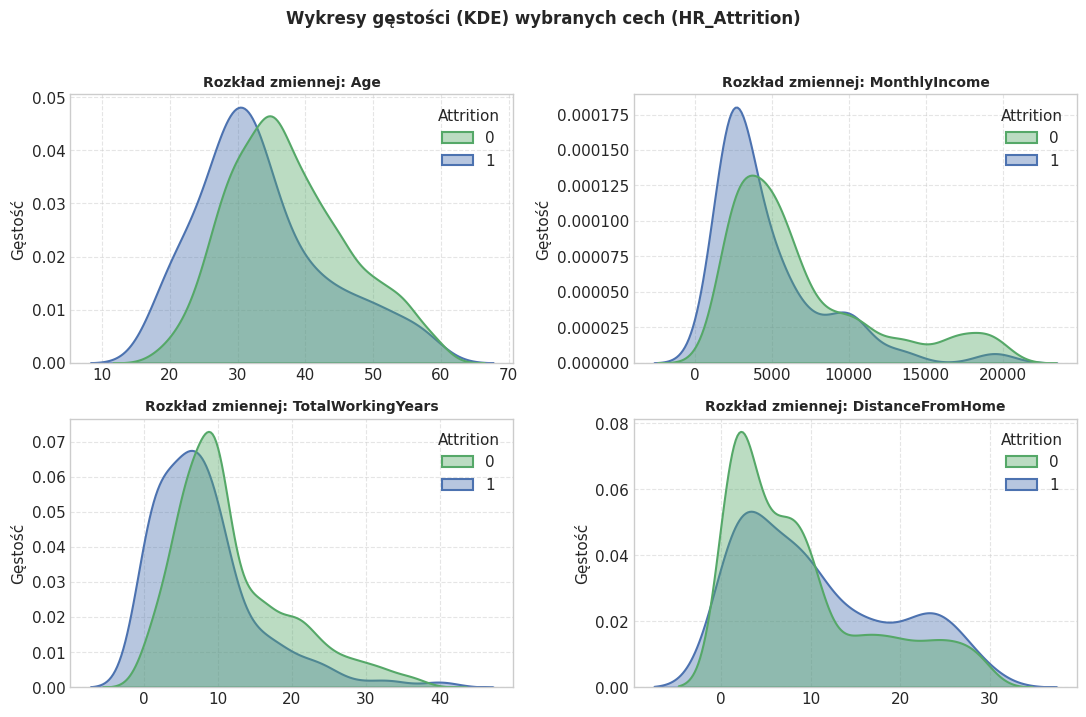

In [2]:
datasets = {}

# --- Pobieranie Credit Risk ---
print("Pobieranie bazy: Credit_Risk...")
credit_data = fetch_ucirepo(id=350)
X_credit = credit_data.data.features
y_credit = credit_data.data.targets.squeeze()

credit_column_mapping = {
    'X1': 'Limit_Balance', 'X2': 'Gender', 'X3': 'Education', 'X4': 'Marital_Status',
    'X5': 'Age', 'X6': 'Repayment_Status_Sept', 'X7': 'Repayment_Status_Aug',
    'X8': 'Repayment_Status_Jul', 'X9': 'Repayment_Status_Jun', 'X10': 'Repayment_Status_May',
    'X11': 'Repayment_Status_Apr', 'X12': 'Bill_Amount_Sept', 'X13': 'Bill_Amount_Aug',
    'X14': 'Bill_Amount_Jul', 'X15': 'Bill_Amount_Jun', 'X16': 'Bill_Amount_May',
    'X17': 'Bill_Amount_Apr', 'X18': 'Previous_Payment_Sept', 'X19': 'Previous_Payment_Aug',
    'X20': 'Previous_Payment_Jul', 'X21': 'Previous_Payment_Jun', 'X22': 'Previous_Payment_May',
    'X23': 'Previous_Payment_Apr'
}
X_credit = X_credit.rename(columns=credit_column_mapping)
datasets['Credit_Risk'] = {'X': X_credit, 'y': y_credit}

# --- Pobieranie Telco Churn ---
print("Pobieranie bazy: Telco_Churn...")
df_telco = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "blastchar/telco-customer-churn", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')
df_telco = df_telco.dropna()
le = LabelEncoder()
for col in df_telco.select_dtypes(include=['object']).columns:
    if col != 'customerID':
        df_telco[col] = le.fit_transform(df_telco[col])

datasets['Telco_Churn'] = {
    'X': df_telco.drop(columns=['customerID', 'Churn']),
    'y': df_telco['Churn']
}

# --- Pobieranie HR Attrition ---
print("Pobieranie bazy: HR_Attrition...")
df_hr = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "pavansubhasht/ibm-hr-analytics-attrition-dataset", "WA_Fn-UseC_-HR-Employee-Attrition.csv")
for col in df_hr.select_dtypes(include=['object']).columns:
    df_hr[col] = le.fit_transform(df_hr[col])

datasets['HR_Attrition'] = {
    'X': df_hr.drop(columns=['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']),
    'y': df_hr['Attrition']
}


# 1. KONFIGURACJA STYLU
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11


# 2. DEFINICJE FUNKCJI WIZUALIZUJĄCYCH (BEZ NUMERÓW W TYTUŁACH)
def plot_target_distribution(df, target_col, dataset_name):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    counts = df[target_col].value_counts().sort_index()
    percentages = df[target_col].value_counts(normalize=True).sort_index() * 100

    bars = sns.barplot(x=counts.index, y=counts.values, palette=['#55a868', '#dd8452'], ax=ax, edgecolor='.3')
    for bar, pct in zip(bars.patches, percentages.values):
        height = bar.get_height()
        ax.annotate(f"{height:,.0f}\n({pct:.1f}%)", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333333")

    ax.set_title(f"Rozkład zmiennej docelowej ({dataset_name})", pad=12, fontweight="bold")
    ax.set_xlabel("Klasa Targetu", labelpad=8)
    ax.set_ylabel("Liczność obserwacji", labelpad=8)
    ax.set_ylim(0, counts.max() * 1.2)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(df, dataset_name):
    fig, ax = plt.subplots(figsize=(8, 7))
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=False,
                fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .75, "label": "Współczynnik korelacji Pearsona (r)"}, ax=ax)
    ax.set_title(f"Macierz korelacji cech ({dataset_name})", pad=12, fontweight="bold")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_density_grid(df, target_col, features, dataset_name):
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.kdeplot(data=df, x=feature, hue=target_col, common_norm=False, fill=True, alpha=0.4, palette=["#55a868", "#4c72b0"], linewidth=1.5, ax=ax)
        ax.set_title(f"Rozkład zmiennej: {feature}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Gęstość")
        ax.grid(True, linestyle="--", alpha=0.5)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Wykresy gęstości (KDE) wybranych cech ({dataset_name})", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# 3. WYWOŁANIE WYKRESÓW
print("\n--- Credit_Risk ---")
df_credit_full = datasets['Credit_Risk']['X'].copy()
df_credit_full['default'] = datasets['Credit_Risk']['y']
plot_target_distribution(df_credit_full, 'default', 'Credit_Risk')
plot_correlation_matrix(df_credit_full, 'Credit_Risk')
plot_density_grid(df_credit_full, 'default', ['Limit_Balance', 'Age', 'Bill_Amount_Sept', 'Previous_Payment_Sept'], 'Credit_Risk')

print("\n--- Telco_Churn ---")
df_telco_full = datasets['Telco_Churn']['X'].copy()
df_telco_full['Churn'] = datasets['Telco_Churn']['y']
plot_target_distribution(df_telco_full, 'Churn', 'Telco_Churn')
plot_correlation_matrix(df_telco_full, 'Telco_Churn')
plot_density_grid(df_telco_full, 'Churn', ['tenure', 'MonthlyCharges', 'TotalCharges'], 'Telco_Churn')

print("\n--- HR_Attrition ---")
df_hr_full = datasets['HR_Attrition']['X'].copy()
df_hr_full['Attrition'] = datasets['HR_Attrition']['y']
plot_target_distribution(df_hr_full, 'Attrition', 'HR_Attrition')
plot_correlation_matrix(df_hr_full, 'HR_Attrition')
plot_density_grid(df_hr_full, 'Attrition', ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'DistanceFromHome'], 'HR_Attrition')

In [3]:
results = {}

for name, data in datasets.items():
    print(f"\n{'='*50}\nROZPOCZYNAM ANALIZĘ DLA ZBIORU: {name}\n{'='*50}")

    # --- PRZYGOTOWANIE ZBIORÓW TRENINGOWYCH I TESTOWYCH ---
    X_train, X_test, y_train, y_test = train_test_split(data['X'], data['y'], test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=data['X'].columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=data['X'].columns)

    # ETAP 1: Benchmarking (Regresja vs Zoptymalizowany XGBoost)
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_scaled, y_train)
    lr_preds = lr_model.predict_proba(X_test_scaled)[:, 1]
    lr_preds_class = lr_model.predict(X_test_scaled)

    # Optymalizacja hiperparametrów XGBoost (RandomizedSearchCV)
    xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    param_dist = {
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0]
    }
    xgb_search = RandomizedSearchCV(xgb_base, param_distributions=param_dist, n_iter=10,
                                    scoring='roc_auc', cv=3, random_state=42, n_jobs=-1)
    xgb_search.fit(X_train_scaled, y_train)
    xgb_best = xgb_search.best_estimator_

    # Predykcje i kalibracja progu odcięcia dla F1-score na zbiorze treningowym
    xgb_preds = xgb_best.predict_proba(X_test_scaled)[:, 1]
    xgb_train_preds = xgb_best.predict_proba(X_train_scaled)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, xgb_train_preds)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]
    xgb_preds_class = (xgb_preds >= best_threshold).astype(int)

    auc_lr = roc_auc_score(y_test, lr_preds)
    f1_lr = f1_score(y_test, lr_preds_class)
    auc_xgb = roc_auc_score(y_test, xgb_preds)
    f1_xgb = f1_score(y_test, xgb_preds_class)

    print(f"[H1] Skuteczność - {name}:")
    print(f"  Regresja: AUC = {auc_lr:.3f}, F1 = {f1_lr:.3f}")
    print(f"  XGBoost : AUC = {auc_xgb:.3f}, F1 = {f1_xgb:.3f} (optymalny próg: {best_threshold:.2f})")

    # Inicjalizacja Explainerów
    explainer_shap = shap.TreeExplainer(xgb_best)

    # ETAP 2: Odporność na zaszumienie Strict Local-to-Local (SHAP vs LIME)
    np.random.seed(42)
    noise = np.random.normal(0, 0.1, X_test_scaled.shape)
    X_test_noisy = X_test_scaled + noise

    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train_scaled.values, feature_names=data['X'].columns, class_names=['0', '1'], mode='classification'
    )

    num_cols = len(data['X'].columns)
    shap_corrs, lime_corrs = [], []

    # Test na 50 obserwacjach - perspektywa ściśle lokalna
    for i in range(50):
        # -- Stabilność LIME --
        exp_orig = explainer_lime.explain_instance(X_test_scaled.iloc[i].values, xgb_best.predict_proba, num_features=num_cols)
        exp_noisy = explainer_lime.explain_instance(X_test_noisy.iloc[i].values, xgb_best.predict_proba, num_features=num_cols)

        d_orig = dict(exp_orig.local_exp[1])
        d_noisy = dict(exp_noisy.local_exp[1])

        ranks_orig_lime = [d_orig.get(idx, 0) for idx in range(num_cols)]
        ranks_noisy_lime = [d_noisy.get(idx, 0) for idx in range(num_cols)]
        corr_lime, _ = spearmanr(np.abs(ranks_orig_lime), np.abs(ranks_noisy_lime))
        if not np.isnan(corr_lime): lime_corrs.append(corr_lime)

        # -- Stabilność SHAP (na tej samej instancji co LIME) --
        shap_orig = explainer_shap.shap_values(X_test_scaled.iloc[i:i+1])[0]
        shap_noisy = explainer_shap.shap_values(X_test_noisy.iloc[i:i+1])[0]
        corr_shap, _ = spearmanr(np.abs(shap_orig), np.abs(shap_noisy))
        if not np.isnan(corr_shap): shap_corrs.append(corr_shap)

    print(f"[H2] Średnia Stabilność Lokalna (Spearman) - {name}:")
    print(f"  Korelacja SHAP: {np.mean(shap_corrs):.3f}")
    print(f"  Korelacja LIME: {np.mean(lime_corrs):.3f}")

    # ETAP 3: Demaskowanie wycieku danych (Proxy Target Leakage)
    X_train_leak, X_test_leak = X_train_scaled.copy(), X_test_scaled.copy()

    # Wybieram pierwszą kolumnę z brzegu - realistyczny wyciek pośredni
    leak_col = X_train_scaled.columns[0]
    X_train_leak[leak_col] = X_train_scaled[leak_col] * 0.5 + y_train.values * 0.5
    X_test_leak[leak_col] = X_test_scaled[leak_col] * 0.5 + y_test.values * 0.5

    xgb_leak = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_leak.fit(X_train_leak, y_train)
    auc_leak = roc_auc_score(y_test, xgb_leak.predict_proba(X_test_leak)[:, 1])

    explainer_leak = shap.TreeExplainer(xgb_leak)
    shap_values_leak = explainer_leak.shap_values(X_test_leak)

    # Wkład zmanipulowanej zmiennej
    leak_importance = np.abs(shap_values_leak).mean(axis=0)
    leak_idx = list(X_train_leak.columns).index(leak_col)
    leak_share = leak_importance[leak_idx] / np.sum(leak_importance)

    print(f"[H3] Demaskowanie Proxy Leakage ({leak_col}) - {name}:")
    print(f"  Fałszywy AUC (z ukrytym wyciekiem) : {auc_leak:.3f}")
    print(f"  Wpływ zmiennej (SHAP) na decyzję : {leak_share*100:.1f}%\n")


ROZPOCZYNAM ANALIZĘ DLA ZBIORU: Credit_Risk
[H1] Skuteczność - Credit_Risk:
  Regresja: AUC = 0.727, F1 = 0.353
  XGBoost : AUC = 0.784, F1 = 0.542 (optymalny próg: 0.27)
[H2] Średnia Stabilność Lokalna (Spearman) - Credit_Risk:
  Korelacja SHAP: 0.715
  Korelacja LIME: 0.539
[H3] Demaskowanie Proxy Leakage (Limit_Balance) - Credit_Risk:
  Fałszywy AUC (z ukrytym wyciekiem) : 1.000
  Wpływ zmiennej (SHAP) na decyzję : 76.6%


ROZPOCZYNAM ANALIZĘ DLA ZBIORU: Telco_Churn
[H1] Skuteczność - Telco_Churn:
  Regresja: AUC = 0.831, F1 = 0.551
  XGBoost : AUC = 0.833, F1 = 0.606 (optymalny próg: 0.37)
[H2] Średnia Stabilność Lokalna (Spearman) - Telco_Churn:
  Korelacja SHAP: 0.927
  Korelacja LIME: 0.762
[H3] Demaskowanie Proxy Leakage (gender) - Telco_Churn:
  Fałszywy AUC (z ukrytym wyciekiem) : 1.000
  Wpływ zmiennej (SHAP) na decyzję : 83.5%


ROZPOCZYNAM ANALIZĘ DLA ZBIORU: HR_Attrition
[H1] Skuteczność - HR_Attrition:
  Regresja: AUC = 0.771, F1 = 0.475
  XGBoost : AUC = 0.767, F1 = 0.